In [1]:
import os

if os.getcwd().split("/")[-1] != "neurolib":
    os.chdir('..')

os.chdir('..')
datadir = os.path.join(os.getcwd(), "neurolib", "whole-brain")

print(datadir)

/home/lena/Promotion/neurolib/neurolib/whole-brain


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io
from numba.typed import Dict
from numba.core import types
import pickle

from neurolib.models.wc import WCModel
from neurolib.utils.stimulus import ZeroInput
from neurolib.control.optimal_control import oc_wc, cost_functions

import nctpy.utils
import nctpy.metrics

import matplotlib as mpl
label_size= 20
mpl.rcParams['xtick.labelsize'] = label_size
mpl.rcParams['ytick.labelsize'] = label_size
mpl.rcParams['font.size'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['figure.titlesize'] = label_size
mpl.rcParams['lines.linewidth'] = 1


# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2

weights = Dict.empty(
        key_type=types.unicode_type,
        value_type=types.float64,
    )

weights["w_2"] = 1.0
weights["w_1"] = 0.0
weights["w_1T"] = 0.0
weights["w_1D"] = 0.0

In [3]:
N = 100

folders = ["NAP_002", "NAP_003", "NAP_005", "NAP_007", "NAP_009", "NAP_010", "NAP_011", "NAP_012", "NAP_013", "NAP_014", "NAP_015", "NAP_016", "NAP_018", "NAP_020", "NAP_022", "NAP_024", "NAP_025", "NAP_026", "NAP_027", "NAP_028", "NAP_029", "NAP_031", "NAP_032", "NAP_033", "NAP_035", "NAP_036"]
cmat_sum = np.zeros((N,N))
dmat_sum = np.zeros((N,N))

for f in folders:
    path = os.path.join(os.getcwd(), "data", "structural_data", "Sch100", f, "SC", "DTI_CM.mat")
    cmat_sum += scipy.io.loadmat(path)["SC"]
    path = os.path.join(os.getcwd(), "data", "structural_data", "Sch100", f, "SC", "DTI_LEN.mat")
    dmat_sum += scipy.io.loadmat(path)["LEN"]

cmat_av = cmat_sum/len(folders)
dmat_av = dmat_sum/len(folders)

In [4]:
coords = [[1.6, 0.0], [1.7, 0.1]] #1st: multistable     // 2nd: unistable synchronized

data_0, data_1, data_2 = dict(), dict(), dict()
data_0["coordinates"] = coords[0]
data_1["coordinates"] = coords[0]
data_2["coordinates"] = coords[1]
lng = int(4*1e3)

for d in [data_0, data_1, data_2]:
    d["weights"] = np.array([-200., -400., -600.])
    d["control"] = [None] * len(data_0["weights"])
    d["state"] = [None] * len(data_0["weights"])
    d["init_state"] = None
    d["energy_input"] = np.zeros((len(d["weights"])))
    d["sync_cost"] = np.zeros((len(d["weights"])))
    d["state_uncontrolled"] = np.zeros((N,2,lng))

data_1["weights"] *= -1

In [5]:
def setparams(model):
    model.params.c_excinh = 12  # local E-I coupling
    model.params.signalV = 80.0
    model.params.K_gl = 0.5  # global coupling strength
    model.params.a_exc = 1.  # excitatory gain
    model.params.a_inh = 1.  # inhibitory gain
    model.params.mu_exc = 5.0  # excitatory firing threshold
    model.params.mu_inh = 5.0  # inhibitory firing threshold

def plot_control(c, s, dur, dt, filename=None, title=None):
    fig, ax = plt.subplots(2,1, figsize=(12,6), sharex=True)
    time_array = np.arange(0, dur+dt, dt)

    cmax = np.amax(np.abs(c))
    y1lim = [-cmax* 1.1, cmax* 1.1]

    for n in range(N):
        ax[0].plot(time_array, s[n,0,:])
        ax[1].plot(time_array, c[n,0,:])

    ax[0].set_xlim(0, dur)

    ax[1].set_ylim(y1lim)

    ax[1].set_xlabel("Time")
    ax[0].set_ylabel("Activity")
    ax[1].set_ylabel("Control")

    plt.subplots_adjust(
                    wspace=0.15,
                    hspace=0.1)
    
    fig.align_ylabels([ax[0]])
    
    if title is not None:
        fig.suptitle(title)

    if filename is not None:
        plt.savefig(filename, bbox_inches='tight', dpi=200)

    plt.show()
    return

def get_results(d, wi, mc):
    d["control"][wi] = mc.control.copy()
    d["state"][wi] = mc.get_xs()
    d["energy_input"][wi] = cost_functions.control_strength_cost(mc.control, weights, dt)
    d["sync_cost"][wi] = (mc.compute_total_cost() - d["energy_input"][wi])/d["weights"][wi]

def dump_data():
    with open(os.path.join(datadir, 'wb.pickle'), 'wb') as f:
        pickle.dump([data_0, data_1, data_2], f)

controlmat = np.zeros((N,2))
controlmat[:,0] = 1

costmat = np.zeros((N, 2))
costmat[:,0] = 1.

duration = 400.
target_period = 1

int0 = 0
int1 = None

max_cntrl = 5
pr = np.arange(0,101,1)
dt = 0.1

------------------- seed =  1


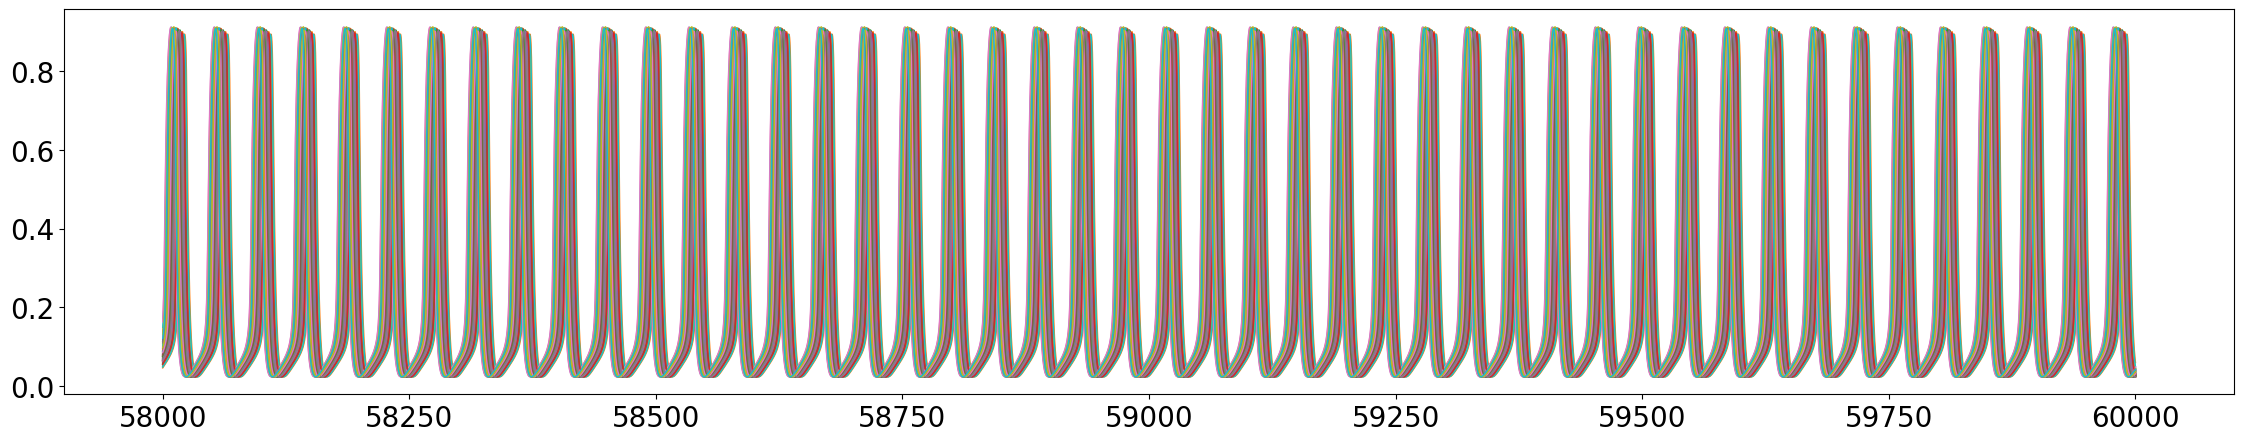

/home/lena/Promotion/neurolib/neurolib/control/optimal_control/cost_functions.py:336: NumbaPendingDeprecationWarning: 
Encountered the use of a type that is scheduled for deprecation: type 'reflected list' found for argument 'interval' of function 'getmean_vt'.

For more information visit https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-reflection-for-list-and-set-types

File "neurolib/control/optimal_control/cost_functions.py", line 315:
@numba.njit
def getmean_vt(
^

  xmean = getmean_vt(x_sim, interval)
/home/lena/.local/lib/python3.10/site-packages/numba/core/ir_utils.py:2149: NumbaPendingDeprecationWarning: 
Encountered the use of a type that is scheduled for deprecation: type 'reflected list' found for argument 'interval' of function 'var_cost'.

For more information visit https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-reflection-for-list-and-set-types

File "neurolib/control/optimal_control/cost_functions.py", lin

0.032164549250778954


/home/lena/.local/lib/python3.10/site-packages/numba/core/ir_utils.py:2149: NumbaPendingDeprecationWarning: 
Encountered the use of a type that is scheduled for deprecation: type 'reflected list' found for argument 'interval' of function 'cc_cost'.

For more information visit https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-reflection-for-list-and-set-types

File "neurolib/control/optimal_control/cost_functions.py", line 415:
@numba.njit
def cc_cost(
^

  warnings.warn(NumbaPendingDeprecationWarning(msg, loc=loc))


-0.6242257109598518
------------------- seed =  25


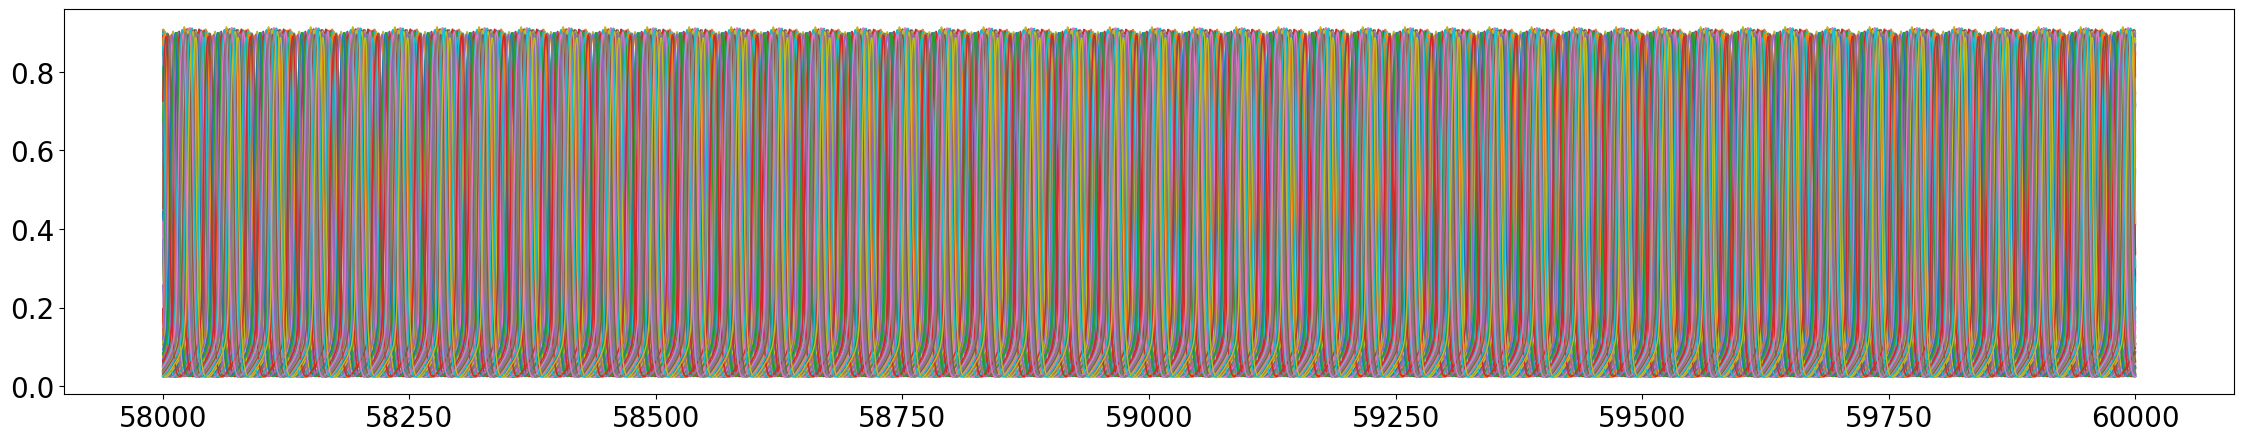

0.08426829728692982
-0.025985539150927384


In [6]:
point = 0
seed = [1, 25]

#for s in np.arange(0,50,1):
for i_s, s in enumerate(seed):

    print("------------------- seed = ", s)

    model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=s)
    testd = 60.*1e3     # needs to stay 60!!!!!
    dt = model.params.dt
    model.params.duration = testd
    model.params.seed = s
    setparams(model)

    #zero_input = ZeroInput().generate_input(duration=testd+model.params.dt, dt=model.params.dt)
    #input = zero_input.copy()
    #input[0,int(0.*1e3/dt):int(5.*1e3/dt)] = 1.

    #print(model.params.exc_init[0,0])

    model.params.exc_ext_baseline = data_0["coordinates"][0]
    model.params.exc_inh_baseline = data_0["coordinates"][1]

    #model.params.exc_ext = input
    model.run()

    plt.figure(figsize=(28,5))

    for n in range(N):
        plt.plot(model.t[-int(2.*1e3/dt):], model.exc[n,-int(2.*1e3/dt):], linewidth=1)
    plt.show()

    nmaxdelay = model.getMaxDelay()
    einit = np.zeros((N, nmaxdelay+1))
    iinit = np.zeros((N, nmaxdelay+1))

    state = np.zeros((N,2,lng))

    for n in range(N):
        einit[n,:] = model.exc[n,-nmaxdelay-1:]
        iinit[n,:] = model.inh[n,-nmaxdelay-1:]
        state[n,0,:] = model.exc[n, -lng:]

    if i_s == 0:
        data_0["init_state"] = [einit, iinit]
        data_0["state_uncontrolled"] = state.copy()
    else:
        data_1["init_state"] = [einit, iinit]
        data_1["state_uncontrolled"] = state.copy()

    var_cost_asyn = np.sum(cost_functions.var_cost(state, costmat, [0,lng], dt)[0,:])*dt
    print(var_cost_asyn)

    cc_cost = np.sum(cost_functions.cc_cost(state, costmat, [0,lng], dt)[0,:])*dt
    print(cc_cost)

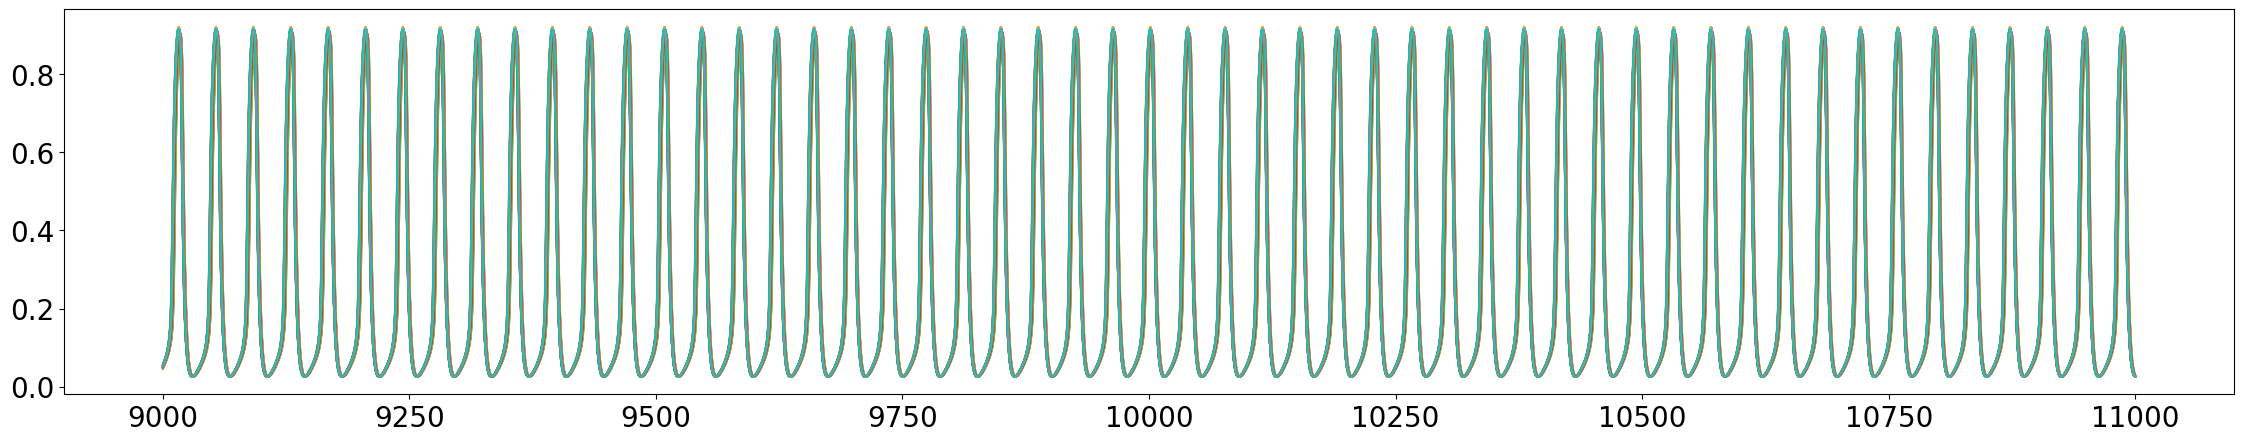

0.002332105821483664
-0.9775374609292389


In [32]:
model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=0)
testd = 11.*1e3   ## needs to stay 11
dt = model.params.dt
model.params.duration = testd
setparams(model)

model.params.exc_ext_baseline = data_2["coordinates"][0]
model.params.exc_inh_baseline = data_2["coordinates"][1]

#model.params.exc_ext = input
model.run()

plt.figure(figsize=(28,5))

for n in range(N):
    plt.plot(model.t[-int(2.*1e3/dt):], model.exc[n,-int(2.*1e3/dt):], linewidth=1)
plt.show()

nmaxdelay = model.getMaxDelay()
einit = np.zeros((N, nmaxdelay+1))
iinit = np.zeros((N, nmaxdelay+1))

state = np.zeros((N,2,lng))

for n in range(N):
    einit[n,:] = model.exc[n,-nmaxdelay-1:]
    iinit[n,:] = model.inh[n,-nmaxdelay-1:]
    state[n,0,:] = model.exc[n, -lng:]

data_2["init_state"] = [einit, iinit]
data_2["state_uncontrolled"] = state.copy()

var_cost_asyn = np.sum(cost_functions.var_cost(state, costmat, [0,lng], dt)[0,:])*dt
print(var_cost_asyn)

cc_cost = np.sum(cost_functions.cc_cost(state, costmat, [0,lng], dt)[0,:])*dt
print(cc_cost)

In [6]:
with open(os.path.join(datadir, 'wb.pickle'), 'rb') as f:
    data_read = pickle.load(f)

[data_0, data_1, data_2] = data_read

------------------------------------------------------------ wi =  0
------------------------------------------------------------ wi =  1
------------------------------------------------------------ wi =  2
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -5.940280805385156
Cost in iteration 1: -78.96167551556655
Final cost : -78.96167551556655
Compute control for a deterministic system
Cost in iteration 0: -78.96167551556655
Cost in iteration 1: -80.98882361726378
Cost in iteration 2: -84.77890293236759
Cost in iteration 3: -91.34561296121376
Cost in iteration 4: -100.81031750973635
Final cost : -100.81031750973635
Compute control for a deterministic system
Cost in iteration 0: -100.81031750973635
Cost in iteration 1: -105.1641869617909
Cost in iteration 2: -105.1641869617909
Converged in iteration 2 with cost -105.1641869617909
Final cost : -105.1641869617909
Compute control for a deterministic system
Cost in iteration 0: 

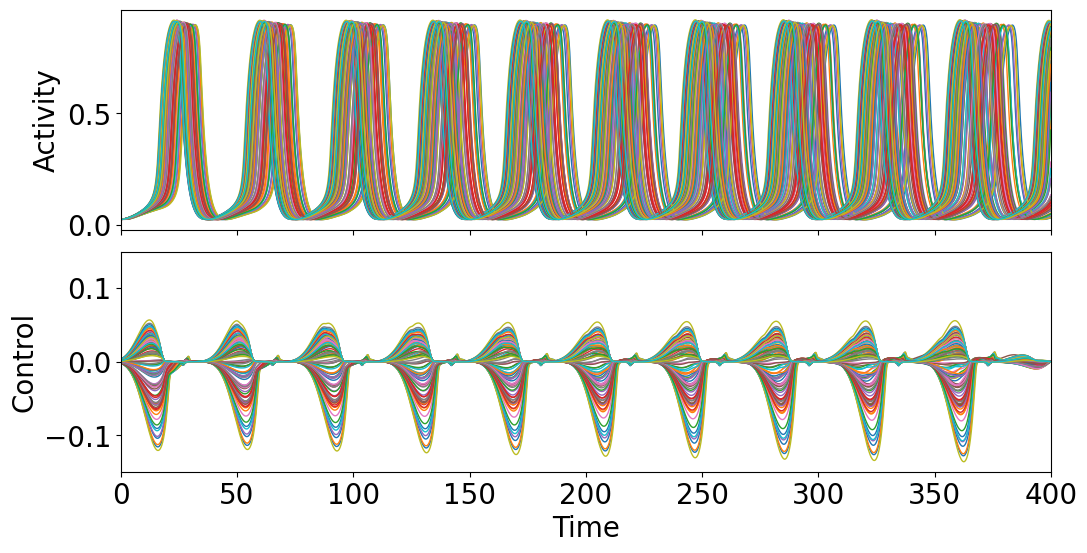

In [11]:
it = 4

#for d in [data_0, data_1, data_2]:
for d in [data_2]:

    for wi in range(3):
        print("------------------------------------------------------------ wi = ", wi)

        if wi != 2: continue

        model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=0)
        model.params.exc_init = d["init_state"][0]
        model.params.inh_init = d["init_state"][1]
        setparams(model)

        model.params["exc_ext_baseline"] =  d["coordinates"][0]
        model.params["inh_ext_baseline"] =  d["coordinates"][1]
        model.params.duration = duration

        model.run()

        model_controlled = oc_wc.OcWc(model, target_period, print_array=pr, cost_interval=(int0, int1), control_interval=(int0, int1), cost_matrix=costmat, control_matrix=controlmat)
        model_controlled.weights["w_p"] = 0.
        model_controlled.weights["w_2"] = 1.
        model_controlled.weights["w_var"] = d["weights"][wi]

        model_controlled.maximum_control_strength = max_cntrl

        # find initial signal
        # model_controlled.channelwise_optimization = True
        model_controlled.optimize(1)

        for j in range(1):
            model_controlled.grad_method = 0

            for k in range(-2, 4, 2):
                model_controlled.zero_step_encountered = False
                model_controlled.step = 10.**(k)
                model_controlled.optimize(it)

                get_results(d, wi, model_controlled)
                dump_data()

            model_controlled.grad_method = 1

            for k in range(-2, 4, 2):
                model_controlled.zero_step_encountered = False
                model_controlled.step = 10.**(k)
                model_controlled.optimize(it)

                get_results(d, wi, model_controlled)
                dump_data()

            plot_control(model_controlled.control, model_controlled.get_xs(), duration, dt, filename=None, title=None)

In [16]:
print(data_0["weights"])
print(data_1["weights"])
print(data_2["weights"])

[-200. -400. -600.]
[600.0, 800.0, 1000.0]
[-600.0, -1000.0, -2000.0]


In [10]:
data_2["weights"][2] = -2000.

In [33]:
with open(os.path.join(datadir, 'wb.pickle'), 'wb') as f:
    pickle.dump([data_0, data_1, data_2], f)

------------------------------------------------------------ wi =  0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 39.704333563931726
Final cost : 39.704333563931726
Compute control for a deterministic system
Cost in iteration 0: 39.704333563931726
Cost in iteration 1: 39.69969088503853
Cost in iteration 2: 39.69108036817369
Cost in iteration 3: 39.67639747882443
Cost in iteration 4: 39.652871181023755
Final cost : 39.652871181023755
Compute control for a deterministic system
Cost in iteration 0: 39.652871181023755
Cost in iteration 1: 39.590066237064306
Cost in iteration 2: 39.538805589270034
Cost in iteration 3: 39.52205583106607
Cost in iteration 4: 39.50947379407087
Final cost : 39.50947379407087
Compute control for a deterministic system
Cost in iteration 0: 39.50947379407087
Cost in iteration 1: 39.50947379407087
Cost in iteration 2: 39.50947379407087
Converged in iteration 2 with cost 39.50947379407087
Final cost :

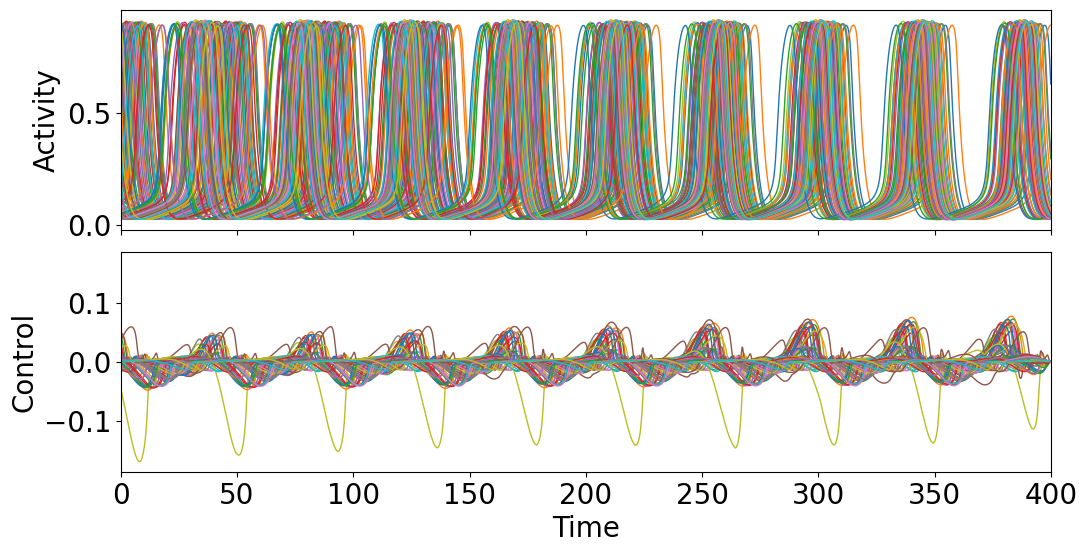

------------------------------------------------------------ wi =  1
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 49.457450336734674
Final cost : 49.457450336734674
Compute control for a deterministic system
Cost in iteration 0: 49.457450336734674
Cost in iteration 1: 49.450008529598755
Cost in iteration 2: 49.43595817166915
Cost in iteration 3: 49.411138420237
Cost in iteration 4: 49.37027662086547
Final cost : 49.37027662086547
Compute control for a deterministic system
Cost in iteration 0: 49.37027662086547
Cost in iteration 1: 49.352973255081295
Cost in iteration 2: 49.32045190150809
Cost in iteration 3: 49.30729572303714
Cost in iteration 4: 49.293697447988926
Final cost : 49.293697447988926
Compute control for a deterministic system
Cost in iteration 0: 49.293697447988926
Cost in iteration 1: 49.293697447988926
Cost in iteration 2: 49.293697447988926
Converged in iteration 2 with cost 49.293697447988926
Final cost 

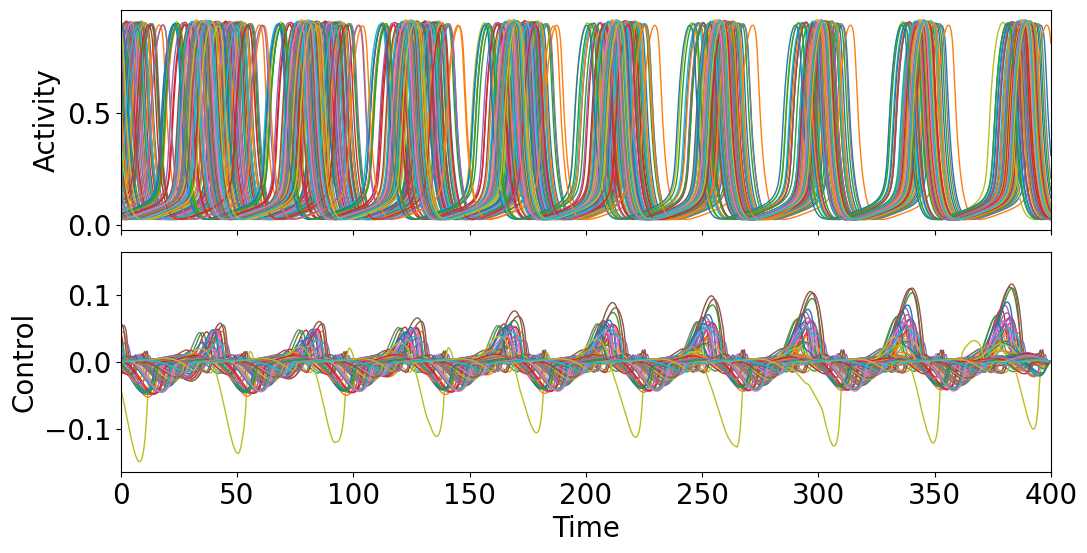

------------------------------------------------------------ wi =  2
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 56.59242451410618
Final cost : 56.59242451410618
Compute control for a deterministic system
Cost in iteration 0: 56.59242451410618
Cost in iteration 1: 56.582477033400565
Cost in iteration 2: 56.566284019265204
Cost in iteration 3: 56.542016674908936
Cost in iteration 4: 56.50299439673868
Final cost : 56.50299439673868
Compute control for a deterministic system
Cost in iteration 0: 56.50299439673868
Cost in iteration 1: 56.41329378661038
Cost in iteration 2: 56.33423497305195
Cost in iteration 3: 56.29578884484058
Cost in iteration 4: 56.27447995407852
Final cost : 56.27447995407852
Compute control for a deterministic system
Cost in iteration 0: 56.27447995407852
Cost in iteration 1: 56.27447995407852
Cost in iteration 2: 56.27447995407852
Converged in iteration 2 with cost 56.27447995407852
Final cost : 56.2

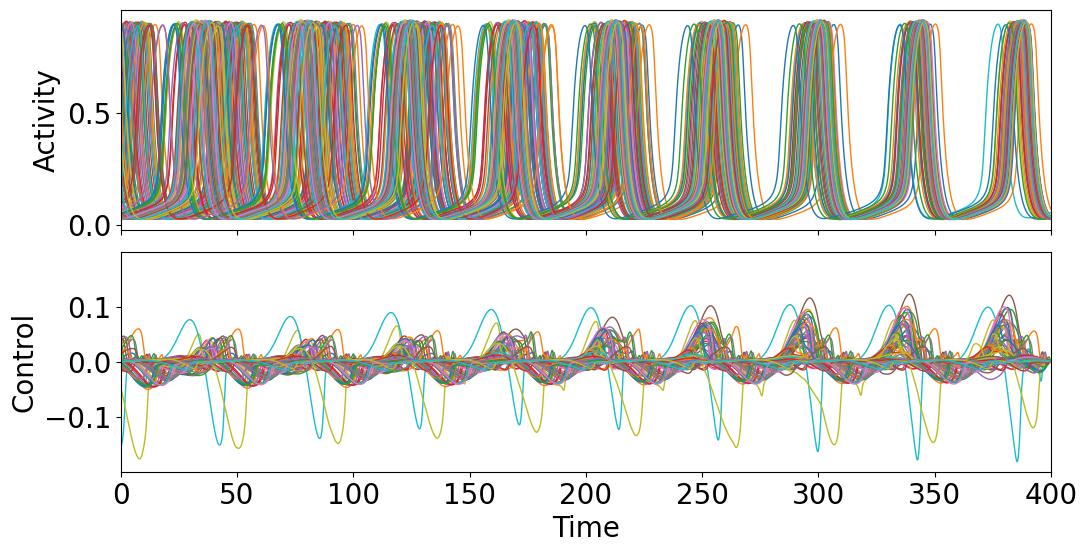

------------------------------------------------------------ wi =  0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -26.26963863210333
Final cost : -26.26963863210333
Compute control for a deterministic system
Cost in iteration 0: -26.26963863210333
Cost in iteration 1: -26.273664846162685
Cost in iteration 2: -26.281039887919718
Cost in iteration 3: -26.294540700020924
Cost in iteration 4: -26.316056628853964
Final cost : -26.316056628853964
Compute control for a deterministic system
Cost in iteration 0: -26.316056628853964
Cost in iteration 1: -26.34074127215087
Cost in iteration 2: -26.360129959244656
Cost in iteration 3: -26.39219854167393
Cost in iteration 4: -26.443561811998244
Final cost : -26.443561811998244
Compute control for a deterministic system
Cost in iteration 0: -26.443561811998244
Cost in iteration 1: -26.443561811998244
Cost in iteration 2: -26.443561811998244
Converged in iteration 2 with cost -26.44356

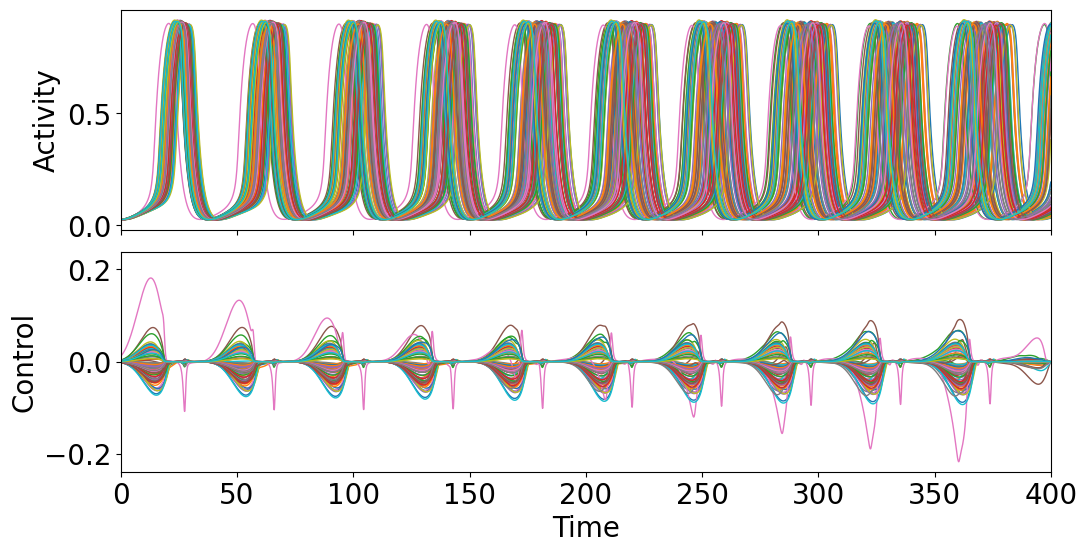

------------------------------------------------------------ wi =  1
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -51.43861543311004
Final cost : -51.43861543311004
Compute control for a deterministic system
Cost in iteration 0: -51.43861543311004
Cost in iteration 1: -51.44726935820799
Cost in iteration 2: -51.46318914371718
Cost in iteration 3: -51.49154298969188
Cost in iteration 4: -51.539554173359555
Final cost : -51.539554173359555
Compute control for a deterministic system
Cost in iteration 0: -51.539554173359555
Cost in iteration 1: -51.55457987647555
Cost in iteration 2: -51.57683637285891
Cost in iteration 3: -51.66478117720101
Cost in iteration 4: -51.688609413709294
Final cost : -51.688609413709294
Compute control for a deterministic system
Cost in iteration 0: -51.688609413709294
Cost in iteration 1: -51.688609413709294
Cost in iteration 2: -51.688609413709294
Converged in iteration 2 with cost -51.688609413

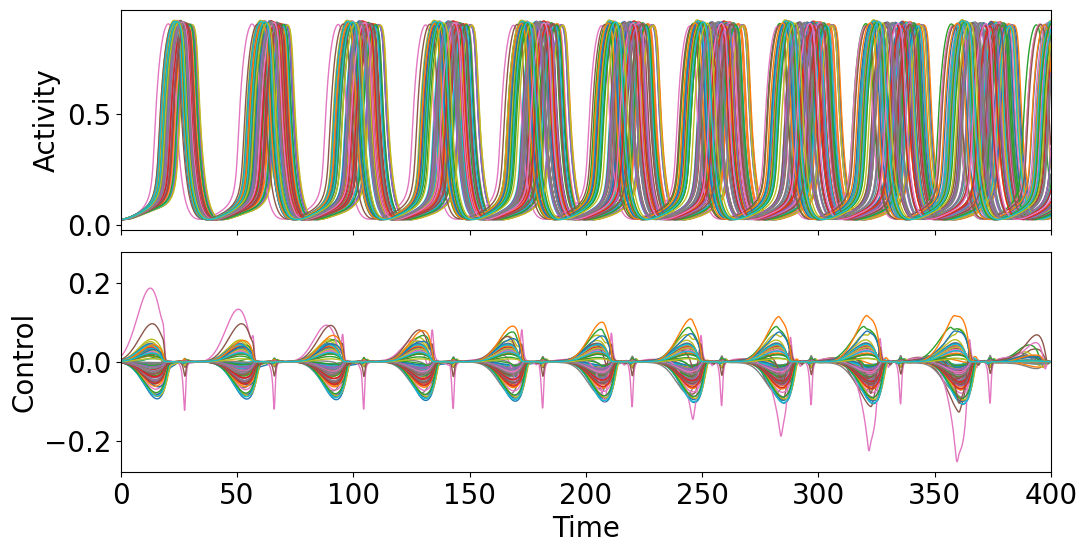

------------------------------------------------------------ wi =  2
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -124.48939558413139
Final cost : -124.48939558413139
Compute control for a deterministic system
Cost in iteration 0: -124.48939558413139
Cost in iteration 1: -124.49354217569548
Cost in iteration 2: -124.50030663946808
Cost in iteration 3: -124.507992441635
Cost in iteration 4: -124.52048457761049
Final cost : -124.52048457761049
Compute control for a deterministic system
Cost in iteration 0: -124.52048457761049
Cost in iteration 1: -124.5240972820576
Cost in iteration 2: -124.53585504603494
Cost in iteration 3: -124.5387340559039
Cost in iteration 4: -124.55107036935709
Final cost : -124.55107036935709
Compute control for a deterministic system
Cost in iteration 0: -124.55107036935709
Cost in iteration 1: -124.55107036935709
Cost in iteration 2: -124.55107036935709
Converged in iteration 2 with cost -124.551

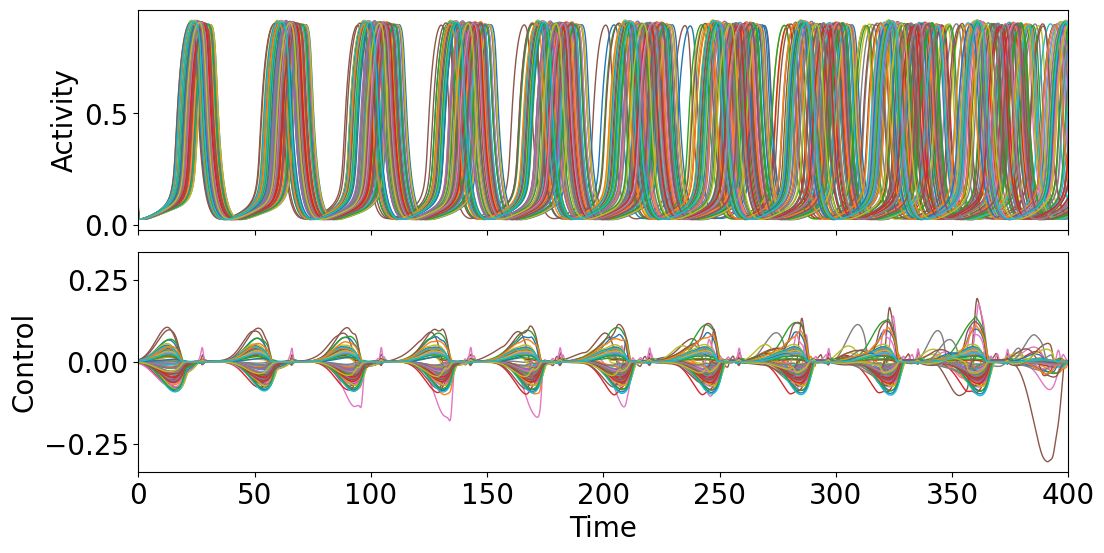

In [ ]:
it = 4

for d in [data_0, data_1, data_2]:
#for d in [data_0, data_2]:

    for wi in range(3):
        print("------------------------------------------------------------ wi = ", wi)

        #if wi not in [2]: continue

        model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=0)
        model.params.exc_init = d["init_state"][0]
        model.params.inh_init = d["init_state"][1]
        setparams(model)

        model.params["exc_ext_baseline"] =  d["coordinates"][0]
        model.params["inh_ext_baseline"] =  d["coordinates"][1]
        model.params.duration = duration
        dt = model.params.dt

        model.run()

        model_controlled = oc_wc.OcWc(model, target_period, print_array=pr, cost_interval=(int0, int1), control_interval=(int0, int1), cost_matrix=costmat, control_matrix=controlmat)
        model_controlled.weights["w_p"] = 0.
        model_controlled.weights["w_2"] = 1.
        model_controlled.weights["w_var"] = d["weights"][wi]

        model_controlled.maximum_control_strength = max_cntrl

        model_controlled.control = d["control"][wi].copy()
        model_controlled.update_input()
        model_controlled.simulate_forward()
        model_controlled.optimize(0)

        for j in range(1):
            model_controlled.grad_method = 0


            model_controlled.channelwise_optimization = True

            for k in range(-2, 4, 2):
                model_controlled.zero_step_encountered = False
                model_controlled.step = 10.**(k)
                model_controlled.optimize(it)

                get_results(d, wi, model_controlled)
                dump_data()

            model_controlled.channelwise_optimization = False

            for k in range(-2, 4, 2):
                model_controlled.zero_step_encountered = False
                model_controlled.step = 10.**(k)
                model_controlled.optimize(it)

                get_results(d, wi, model_controlled)
                dump_data()

            model_controlled.grad_method = 1

            model_controlled.channelwise_optimization = True

            for k in range(-2, 4, 2):
                model_controlled.zero_step_encountered = False
                model_controlled.step = 10.**(k)
                model_controlled.optimize(it)

                get_results(d, wi, model_controlled)
                dump_data()

            model_controlled.channelwise_optimization = False

            for k in range(-2, 4, 2):
                model_controlled.zero_step_encountered = False
                model_controlled.step = 10.**(k)
                model_controlled.optimize(it)

                get_results(d, wi, model_controlled)
                dump_data()

        plot_control(model_controlled.control, model_controlled.get_xs(), duration, dt, filename=None, title=None)

------------------------------------------------------------ wi =  0


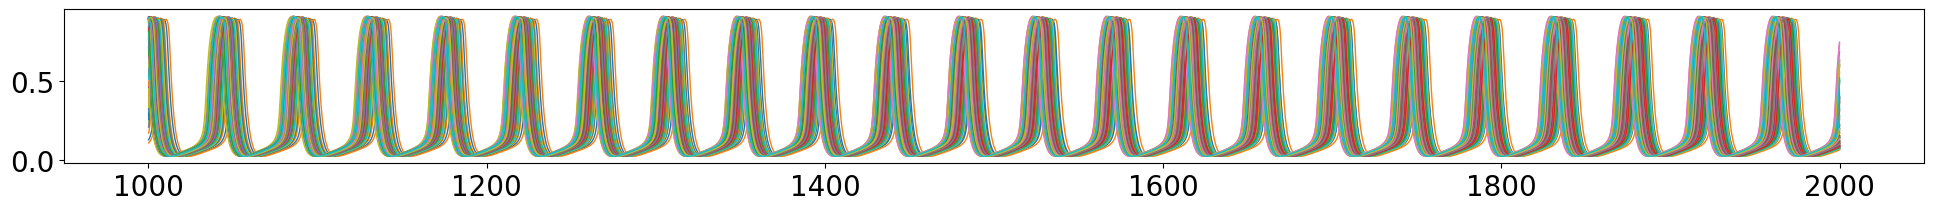

------------------------------------------------------------ wi =  1


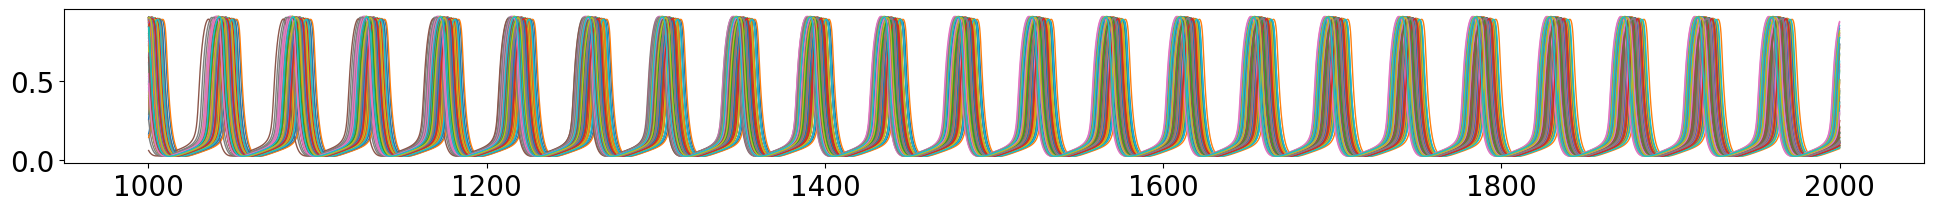

------------------------------------------------------------ wi =  2


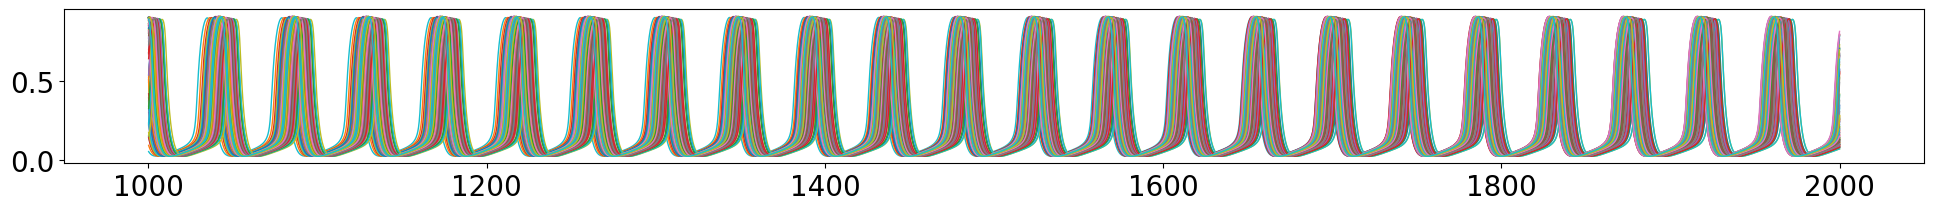

In [15]:
d = data_1


for wi in range(3):
    print("------------------------------------------------------------ wi = ", wi)

    #if wi in [1,2]: continue

    model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=0)
    model.params.exc_init = d["init_state"][0]
    model.params.inh_init = d["init_state"][1]
    setparams(model)

    model.params["exc_ext_baseline"] =  d["coordinates"][0]
    model.params["inh_ext_baseline"] =  d["coordinates"][1]
    model.params.duration = 2. * 1e3
    dt = model.params.dt

    cntrl = np.zeros((N, 2, int(model.params.duration/dt)+1))
    cntrl[:,:,:4001] = d["control"][wi]

    model.params.exc_ext = cntrl[:,0,:]

    model.run()

    plt.figure(figsize=(24,2))
    for n in range(N):
        plt.plot(model.t[-10000:], model.exc[n,-10000:])
        
    plt.show()


# task 1: 

###################### control task 1